In [41]:
import MDAnalysis as mda
from MDAnalysis.transformations import unwrap, center_in_box
import os
import numpy as np
import freud
import matplotlib.pyplot as plt
import tqdm

In [42]:
lipids = 4096

In [43]:
def block_analysis(data, max_size = 10000):

    data = np.array(data)
    n = len(data)

    block_size = 1
    blocking_errors = []
    block_sizes = []

    while block_size <= min(max_size, n//2):

        n_blocks = n // block_size

        n_use = n_blocks * block_size
        data_trimmed = data[:n_use]

        blocks = data_trimmed.reshape(n_blocks, block_size)
        block_means = np.mean(blocks, axis=1)
        
        # Korrigiert: Standard Error of the Mean
        std_error = np.std(block_means, ddof=1) / np.sqrt(n_blocks)

        blocking_errors.append(std_error)
        block_sizes.append(block_size)

        # Exponentiell erhöhen für bessere Abdeckung
        if block_size < 100:
            block_size += 1
        else:
            block_size = int(block_size * 1.2)

    plt.figure(figsize=(8, 5))
    plt.plot(block_sizes, blocking_errors, 'o-')
    plt.xlabel('Block Size')
    plt.ylabel('Standard Error of Mean')
    plt.xscale('log')  # Log-Skala oft hilfreich
    plt.grid(True)
    plt.title('Block Analysis')
    plt.show()
    
    # Plateau-Wert zurückgeben (letzter Wert)
    print(f"Plateau error estimate: {blocking_errors[-1]:.6f}")
    
    return block_sizes, blocking_errors

In [44]:
def running_avg(lst):

    avg_lst = []
    std_lst = []

    for i in tqdm.tqdm(range(len(lst))):

       avg_lst.append(np.mean(lst[:i+1])) 
       std_lst.append(np.std(lst[:i+1]))

    avg_lst, std_lst = np.array(avg_lst), np.array(std_lst)

    plt.plot(avg_lst)

In [45]:
def force_and_radius(R):

    sigma_data = np.loadtxt(os.path.join(dir, f"tether_simulation/data/stress_and_force_{R}.dat"), skiprows=2, usecols=(1,2,3,4))
    sigma_xx, sigma_yy, sigma_zz, force_z = sigma_data[:, 0], sigma_data[:, 1], sigma_data[:, 2], sigma_data[:, 3]

    block_analysis(force_z)

    top_file = os.path.join(dir, f"setup/cylinder_{R}.data")
    traj_file = os.path.join(dir, f"tether_simulation/data/cylinder_sim_{R}.lammpstrj")

    u = mda.Universe(top_file, format="DATA", atom_style = "id resid type charge x y z")
    u.load_new(traj_file, format="LAMMPSDUMP", dt=0.005)

    radii = []

    lipid_atoms = u.select_atoms(f"not type 4")

    for ts in u.trajectory:

        com = lipid_atoms.center_of_mass()

        positions = lipid_atoms.positions

        x = positions[:, 0] - com[0]
        y = positions[:, 1] - com[1]

        r = np.sqrt(x**2 + y**2)

        radii.append(np.mean(r))

    radius = np.mean(radii)

    radii = np.array(radii)

    force = np.abs(np.mean(force_z))

    kappa = force*radius/(2*np.pi)

    print(f"Values for R = {R}")
    print(f"Force {force}")
    print(f"radius {radius} +/- {np.std(radii)}")
    print(f"sigma_zz {np.mean(sigma_zz)}")
    print(f"sigma_xx {np.mean(sigma_xx)}")
    print(f"sigma_yy {np.mean(sigma_yy)}")

    print(f"kappa = {kappa}")

    return force, radius

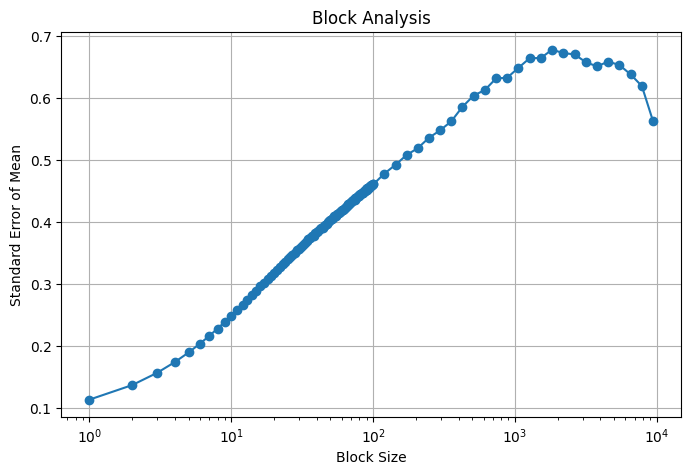

Plateau error estimate: 0.562619
Values for R = 6
Force 1.028730875014494
radius 12.011870179184427 +/- 0.6787282295671571
sigma_zz -0.0006241822741327373
sigma_xx -0.00016293249473228654
sigma_yy 0.00016293249472068506
kappa = 1.9666747224330614


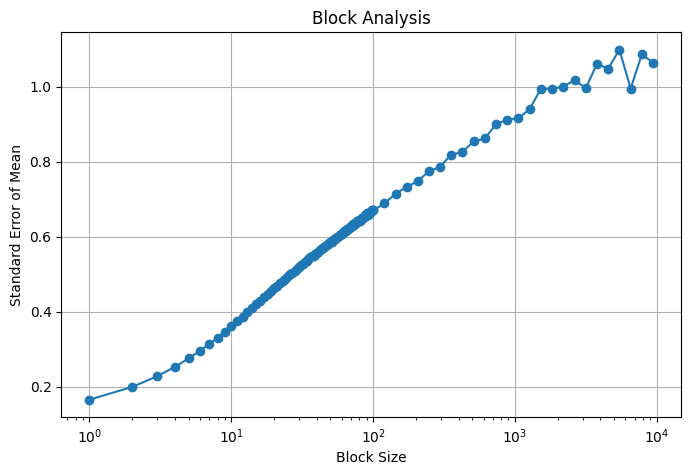

Plateau error estimate: 1.063814
Values for R = 8
Force 1.684659383512853
radius 14.517134973563483 +/- 0.40016547345597053
sigma_zz -0.0008449214487401126
sigma_xx -0.00029134961055659675
sigma_yy 0.0002913496105585746
kappa = 3.892361351652448


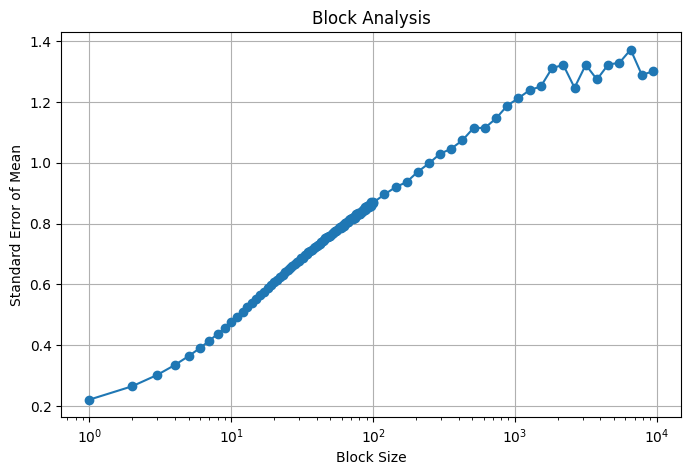

Plateau error estimate: 1.300620
Values for R = 10
Force 0.8528320620565382
radius 18.493395177179288 +/- 0.48587406919908316
sigma_zz -0.00034156682065002343
sigma_xx 0.0001853543668021446
sigma_yy -0.00018535436682034478
kappa = 2.5101536199096954


In [46]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"

rads = ["6", "8", "10"]
results = []

for R in rads:

    results.append(force_and_radius(R))

